# Experiment: Koopman-CE Cases A/B/C

This notebook implements the three benchmark routes in [研究框架.md](../doc/研究框架.md):

- Case A: `standardized GIS` exact degradation baseline
- Case B: `full GIS` anisotropic baseline
- Case C: weakly nonlinear stochastic dynamics with `identity` vs `quadratic` lift

The focus is not only whether dual-whitened Koopman analysis works, but whether it can be split into determinism and nondegeneracy terms that stay aligned with the GIS-side theory and with the causal-emergence interpretation in Liu et al. (2025).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'exp' / 'koopman_ce_cases.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing exp/koopman_ce_cases.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from exp.koopman_ce_cases import (
    build_case_a_score_comparison_dataframe,
    koopman_ce_total_score_from_linear_system,
    liu2025_log_gamma_gis,
    make_case_b_config,
    make_case_c_config,
    plot_case_alignment,
    plot_score_to_score_comparison,
    run_case,
    run_case_c_sweep,
    summarize_case,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)


## Case A：可逆性得分点云比较

这一节不再把 case A 设计成“单个 GIS 的谱对比”，而是改成“多个 GIS 的可逆性得分对比”。图中的每一个点都对应一个独立的 Gaussian iterative system (GIS)，横轴使用 Liu 等（2025）原生框架中的可逆性得分，纵轴使用研究框架中基于双边白化 Koopman 矩阵定义的新可逆性总得分。

### 1. 单个 GIS 的定义

每个系统都满足
$$
x_{t+1} = A x_t + \eta_t,
\qquad
\eta_t \sim \mathcal N(0, \Sigma).
$$

对于 Liu 等（2025）的原生 GIS 框架，我们直接使用论文中的可逆性指标
$$
\log \Gamma_{\alpha}^{\mathrm{GIS}}
= \frac{n}{2}\log(2\pi \alpha)
+ \left(\frac{1}{2} - \frac{\alpha}{4}\right) \log \operatorname{pdet}(A^\top \Sigma^{-1} A)
+ \frac{\alpha}{4} \log \operatorname{pdet}(\Sigma^{-1}).
$$
这里 **不做任何额外标准化**，完全保持 Liu 2025 文章里的原生做法。

对于研究框架中的新定义，我们先构造双边白化 Koopman 矩阵
$$
\bar K = C_{00}^{-1/2} C_{01} C_{11}^{-1/2},
$$
再定义总得分
$$
\mathcal G_{\alpha}^{K}
= \left(\frac{1}{2} - \frac{\alpha}{4}\right) \log \operatorname{pdet}(N_K)
+ \frac{\alpha}{4} \log \operatorname{pdet}(D_K),
$$
其中
$$
D_K = (I - \bar K^\top \bar K)^{-1},
\qquad
N_K = \bar K (I - \bar K^\top \bar K)^{-1} \bar K^\top.
$$

在线性高斯条件下，研究框架已经证明
$$
\log \Gamma_{\alpha}^{\mathrm{GIS}} = C_{\mathrm{marg},\alpha} + \mathcal G_{\alpha}^{K},
$$
因此两者应呈现强线性关系；差异主要来自边缘修正项，而不是通道结构本身。

### 2. 点云中的 GIS 如何设计

为了让每个点尽可能覆盖不同情况，这里混合生成三类 GIS：

1. 对角矩阵 $A$ + 各向同性噪声，系统扫描不同的稳定特征值和噪声强度；
2. 旋转后的 $A$ + 各向同性噪声，用来打破坐标轴对齐；
3. 旋转后的 $A$ + 各向异性噪声，用来观察原生 GIS 得分对噪声尺度的敏感性。

因此，图里的点会同时覆盖：弱噪声/强噪声、近可逆/弱可逆、坐标轴对齐/非对齐、各向同性/各向异性等多种情况。

### 3. 本节要看什么

本节主要看两件事：

1. 当横轴取 Liu 2025 原生 $\log \Gamma_{\alpha}^{\mathrm{GIS}}$、纵轴取新总得分 $\mathcal G_{\alpha}^{K}$ 时，点云是否呈现稳定的单调或近线性关系；
2. 原生 GIS 得分保留了噪声和边缘协方差的绝对尺度，而新总得分是双边白化后的通道总得分，因此它们即使不完全重合，也应在结构上保持一致。

如果这张点云图成立，就说明：即使完全使用 Liu 2025 的原生 GIS 做法、不额外标准化，研究框架中新定义的总得分依然能与它形成系统性的对应关系。


,name,liu_log_gamma,koopman_total_score,marginal_correction,top_whitened_sv,top_native_sv,trace_sigma,is_isotropic_sigma
0,case_a_diag_sigma_0.03,12.3804,1.3798,11.0006,0.98,1067.1111,0.0027,True
1,case_a_diag_sigma_0.06,10.3010,1.3798,8.9212,0.98,266.7778,0.0108,True
2,case_a_diag_sigma_0.10,8.7685,1.3798,7.3887,0.98,96.0400,0.0300,True
3,case_a_diag_sigma_0.18,7.0051,1.3798,5.6254,0.98,29.6420,0.0972,True
4,case_a_diag_sigma_0.03,12.5476,0.8371,11.7105,0.95,1002.7778,0.0027,True


Number of GIS samples: 32
Liu 2025 log-Gamma range: (np.float64(6.489480357583028), np.float64(12.547594110161482))
New Koopman total-score range: (np.float64(-0.5101717873593183), np.float64(1.691435968756848))
Marginal-correction range: (np.float64(5.625369633370997), np.float64(12.650754361769636))


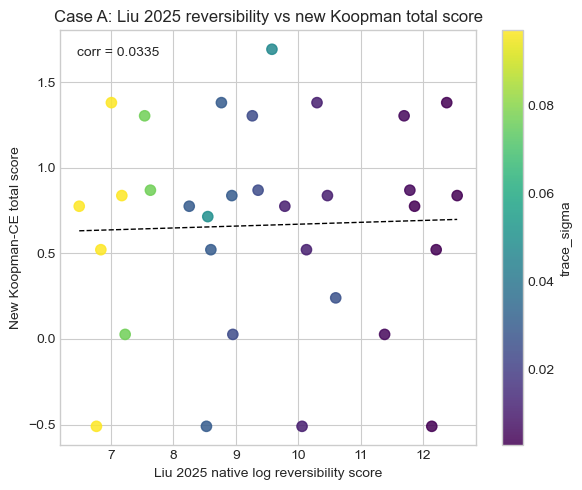

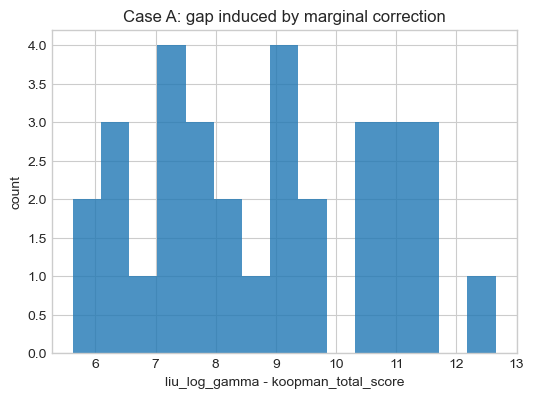

In [2]:
case_a_scores = build_case_a_score_comparison_dataframe(alpha=1.0)
display(case_a_scores.head())
print('Number of GIS samples:', len(case_a_scores))
print('Liu 2025 log-Gamma range:', (case_a_scores['liu_log_gamma'].min(), case_a_scores['liu_log_gamma'].max()))
print('New Koopman total-score range:', (case_a_scores['koopman_total_score'].min(), case_a_scores['koopman_total_score'].max()))
print('Marginal-correction range:', (case_a_scores['marginal_correction'].min(), case_a_scores['marginal_correction'].max()))

fig_a_score, _ = plot_score_to_score_comparison(
    case_a_scores,
    x_col='liu_log_gamma',
    y_col='koopman_total_score',
    title='Case A: Liu 2025 reversibility vs new Koopman total score',
    color_col='trace_sigma',
    xlabel='Liu 2025 native log reversibility score',
    ylabel='New Koopman-CE total score',
)
plt.show()

case_a_scores['score_gap'] = case_a_scores['liu_log_gamma'] - case_a_scores['koopman_total_score']
fig_gap, ax_gap = plt.subplots(figsize=(6.0, 4.2))
ax_gap.hist(case_a_scores['score_gap'], bins=15, color='tab:blue', alpha=0.8)
ax_gap.set_xlabel('liu_log_gamma - koopman_total_score')
ax_gap.set_ylabel('count')
ax_gap.set_title('Case A: gap induced by marginal correction')
plt.show()


## Case B: full GIS anisotropic baseline

This is the exact degradation test for the full framework. The current and future marginals are no longer standardized by isotropic noise, so the experiment checks whether the split objects

- `D_K` capture the determinism-side structure;
- `N_K` capture the nondegeneracy-side structure;
- the combined score remains aligned with the GIS-side closed form.


,case,lift,epsilon,gamma_empirical,gamma_theory,gamma_gap,fro_D,fro_N
0,case_b_full_gis,identity,0.0,2.2845,2.2335,0.0509,9.4495,9.4589


Case B singular values (empirical): [0.9955 0.8774 0.2174]
Case B singular values (theory):    [0.9951 0.8724 0.2235]


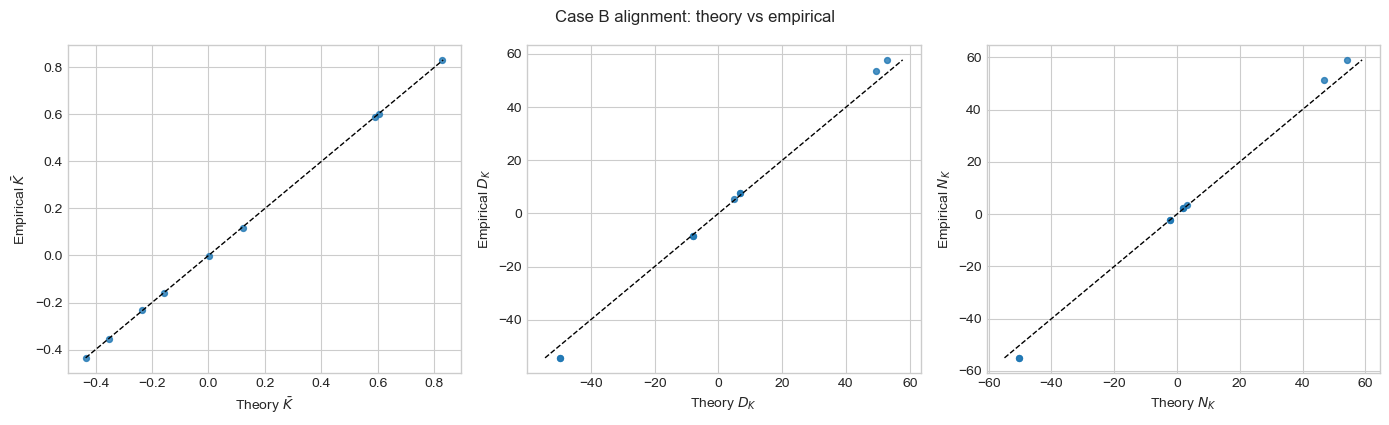

In [3]:
case_b = run_case(make_case_b_config(seed=1, n_steps=14000, burn_in=2500))
display(summarize_case(case_b))
print('Case B singular values (empirical):', np.round(case_b['empirical']['singular_values'], 4))
print('Case B singular values (theory):   ', np.round(case_b['theory']['singular_values'], 4))
fig_b, _ = plot_case_alignment(case_b)
fig_b.suptitle('Case B alignment: theory vs empirical', y=1.05)
plt.show()


## Case C: weakly nonlinear extension

For the nonlinear case we keep the same linear-GIS reference as the zero-order baseline, then ask how fast the Koopman-CE score drifts away as `epsilon` grows. The `quadratic` lift uses richer current observables but still predicts the same 3D future state, which keeps the comparison to the GIS-side reference meaningful.


,lift,epsilon,gamma_gap_abs,gamma_empirical,gamma_theory
0,identity,0.00,0.0071,2.2406,2.2335
1,identity,0.05,0.7080,1.5255,2.2335
2,identity,0.10,1.1047,1.1288,2.2335
3,identity,0.15,1.3810,0.8525,2.2335
4,identity,0.20,1.6326,0.6009,2.2335
5,quadratic,0.00,0.0123,2.2459,2.2335
6,quadratic,0.05,0.7037,1.5298,2.2335
7,quadratic,0.10,1.0970,1.1366,2.2335
8,quadratic,0.15,1.3258,0.9078,2.2335
9,quadratic,0.20,1.2968,0.9367,2.2335


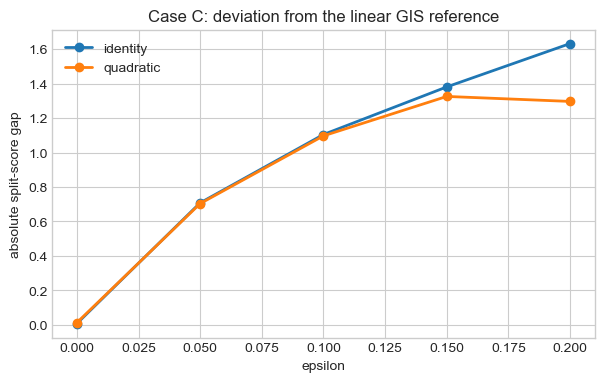

In [4]:
eps_grid = [0.0, 0.05, 0.10, 0.15, 0.20]
case_c_df = run_case_c_sweep(eps_grid, seed=2, n_steps=12000, burn_in=2000)
display(case_c_df)

fig, ax = plt.subplots(figsize=(7, 4))
for lift, frame in case_c_df.groupby('lift'):
    ax.plot(frame['epsilon'], frame['gamma_gap_abs'], marker='o', linewidth=2, label=lift)
ax.set_xlabel('epsilon')
ax.set_ylabel('absolute split-score gap')
ax.set_title('Case C: deviation from the linear GIS reference')
ax.legend()
plt.show()


## Compact comparison

The table below puts the exact baselines and the nonlinear sweep entry points together. In practice, the key readout is:

- A/B should have small split-score gaps and strong spectral agreement;
- C should recover the B baseline at `epsilon = 0`;
- the `quadratic` lift should decay more gracefully than `identity` as nonlinearity grows.


In [5]:
summary_df = pd.concat([
    summarize_case(case_a),
    summarize_case(case_b),
    case_c_df.query('epsilon in [0.0, 0.2]').assign(case='case_c_sweep')[['case', 'lift', 'epsilon', 'gamma_empirical', 'gamma_theory', 'gamma_gap_abs']]
], ignore_index=True)
display(summary_df)


NameError: name 'case_a' is not defined